In [1]:
import sys

sys.path.append("../../BayesFlow")
sys.path.append("../")

import os
if "KERAS_BACKEND" not in os.environ:
    # set this to "torch", "tensorflow", or "jax"
    os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pickle

import keras
import time

import bayesflow as bf

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


In [2]:

parent_dir = os.path.dirname(os.getcwd())

# Spearman-Brown Correction

def spearman(r, k=2):

    return (k*r)/(1+r)


# Read Data

In [22]:
lst_files = os.listdir(parent_dir + '/data_complete/reliability')

In [26]:
lst_files

['reliabilities_uncorrected_dmc_optimized_winsim_priors_sdr_fixed_200_821788.csv',
 'reliabilities_uncorrected_dmc_optimized_updated_priors_sdr_estimated_200_821683_model_data_hedge_hedge2.csv',
 'reliabilities_uncorrected_dmc_optimized_updated_priors_sdr_estimated_250_818798_model_data_hedge_hedge3.csv',
 'reliabilities_uncorrected_dmc_optimized_updated_priors_sdr_fixed_200_821685_model_data_hedge_hedge3.csv',
 'reliabilities_uncorrected_dmc_optimized_winsim_priors_sdr_estimated_200_818802_model_data_hedge_hedge5.csv',
 'reliabilities_uncorrected_dmc_optimized_winsim_priors_sdr_estimated_200_818802_model_data_hedge_hedge4.csv',
 'reliabilities_uncorrected_dmc_optimized_winsim_priors_sdr_fixed_200_818801_model_data_hedge_hedge4.csv',
 'reliabilities_uncorrected_dmc_optimized_updated_priors_sdr_estimated_200_818797_model_data_hedge_hedge5.csv',
 'reliabilities_uncorrected_dmc_optimized_winsim_priors_sdr_estimated_200_818802_model_data_hedge_whitehead2.csv',
 'reliabilities_uncorrected_d

In [48]:
targets = {"818801", "818802", "821685", "821683"}

filtered = [x for x in lst_files if any(t in x for t in targets)]

In [49]:
lst_data = []

for path in filtered:
    lst_data.append(pd.read_csv(parent_dir + '/data_complete/reliability/' + path))

In [50]:
data = pd.concat(lst_data)

In [51]:
data

,Unnamed: 0,A,tau,mu_c,mu_r,b,sd_r,data_set,network_name,spacing
0,0,0.832308,0.628717,0.928447,0.940412,0.925814,0.866187,model_data_hedge_hedge2,dmc_optimized_updated_priors_sdr_estimated_200...,NaN
0,0,0.856685,0.305310,0.869637,0.799294,0.892536,NaN,model_data_hedge_hedge3,dmc_optimized_updated_priors_sdr_fixed_200_821685,NaN
0,0,0.804203,0.581742,0.902708,0.886829,0.899619,0.767399,model_data_hedge_hedge5,dmc_optimized_winsim_priors_sdr_estimated_200_...,NaN
0,0,0.699544,0.426234,0.817651,0.853091,0.742685,0.740909,model_data_hedge_hedge4,dmc_optimized_winsim_priors_sdr_estimated_200_...,NaN
0,0,0.789387,0.726590,0.896709,0.369427,0.947890,NaN,model_data_hedge_hedge4,dmc_optimized_winsim_priors_sdr_fixed_200_818801,NaN
0,0,0.432303,0.980128,0.985359,0.980384,0.971604,0.918026,model_data_hedge_whitehead2,dmc_optimized_winsim_priors_sdr_estimated_200_...,NaN
0,0,0.712330,0.422109,0.894388,0.789849,0.729669,NaN,empirical_study,dmc_optimized_winsim_priors_sdr_fixed_200_818801,narrow
1,1,0.559869,0.248733,0.830645,0.686488,0.452985,NaN,empirical_study,dmc_optimized_winsim_priors_sdr_fixed_200_818801,wide
0,0,0.839202,0.449206,0.876738,0.877103,0.902571,0.773419,model_data_hedge_hedge3,dmc_optimized_updated_priors_sdr_estimated_200...,NaN
0,0,0.646297,0.159893,0.899124,0.864211,0.856899,0.690642,empirical_study,dmc_optimized_winsim_priors_sdr_estimated_200_...,narrow


# Spearman-Brown Correction

In [52]:
data['A_c'] = spearman(data['A'])
data['tau_c'] = spearman(data['tau'])
data['mu_c_c'] = spearman(data['mu_c'])
data['mu_r_c'] = spearman(data['mu_r'])
data['sd_r_c'] = spearman(data['sd_r'])
data['b_c'] = spearman(data['b'])

In [53]:
# Exclude wide spacing condition

data = data[data['spacing'] != 'wide']


In [54]:
data[data['data_set'] == 'empirical_study']

,Unnamed: 0,A,tau,mu_c,mu_r,b,sd_r,data_set,network_name,spacing,A_c,tau_c,mu_c_c,mu_r_c,sd_r_c,b_c
0,0,0.712330,0.422109,0.894388,0.789849,0.729669,NaN,empirical_study,dmc_optimized_winsim_priors_sdr_fixed_200_818801,narrow,0.832001,0.593638,0.944250,0.882587,NaN,0.843709
0,0,0.646297,0.159893,0.899124,0.864211,0.856899,0.690642,empirical_study,dmc_optimized_winsim_priors_sdr_estimated_200_...,narrow,0.785152,0.275703,0.946883,0.927160,0.817017,0.922935
0,0,0.724512,0.426674,0.883568,0.744600,0.581226,NaN,empirical_study,dmc_optimized_updated_priors_sdr_fixed_200_821685,narrow,0.840252,0.598138,0.938185,0.853606,NaN,0.735158
0,0,0.727004,0.318562,0.919575,0.887502,0.873700,0.735266,empirical_study,dmc_optimized_updated_priors_sdr_estimated_200...,narrow,0.841925,0.483197,0.958103,0.940399,0.847439,0.932593


In [55]:
data['sdr'] = '$sd_r$ fixed'
data['priors'] = 'updated'

/tmp/ipykernel_22618/3556821624.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['sdr'] = '$sd_r$ fixed'
/tmp/ipykernel_22618/3556821624.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['priors'] = 'updated'


In [56]:

data['sdr'][data['network_name'].str.contains('estimated', na=False)] = '$sd_r$ estimated'

data['priors'][data['network_name'].str.contains('winsim', na=False)] = 'initial'


data['category'] = data['sdr'] + ', ' + data['priors'] + ' priors'


/tmp/ipykernel_22618/2884954409.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['sdr'][data['network_name'].str.contains('estimated', na=False)] = '$sd_r$ estimated'
/tmp/ipykernel_22618/2884954409.py:1: SettingWithCopyWarning: 
A v

In [57]:
data['network_name'].unique()

array(['dmc_optimized_updated_priors_sdr_estimated_200_821683',
       'dmc_optimized_updated_priors_sdr_fixed_200_821685',
       'dmc_optimized_winsim_priors_sdr_estimated_200_818802',
       'dmc_optimized_winsim_priors_sdr_fixed_200_818801'], dtype=object)

In [58]:
# Rename Data sets

data['data_set'] = data['data_set'].str.replace('model_data_hedge_', '', regex=False)
data['data_set'] = data['data_set'].str.replace('hedge', 'Hedge ', regex=False)
data['data_set'] = data['data_set'].str.replace('whitehead', 'Whitehead ', regex=False)
data['data_set'] = data['data_set'].str.replace('empirical_study', 'Present Study', regex=False)

# Hedge 3 and 4 include Speed-Accuracy Manipulation -> exlude them
data = data[~data['data_set'].isin(['Hedge 3', 'Hedge 4'])]


data['data_set'] = data['data_set'].str.replace('Hedge 3', 'Hedge 3 - ACC', regex=False)
data['data_set'] = data['data_set'].str.replace('Hedge 4', 'Hedge 3 - Speed', regex=False)
data['data_set'] = data['data_set'].str.replace('Hedge 5', 'Hedge 3', regex=False)

/tmp/ipykernel_22618/2082980350.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['data_set'] = data['data_set'].str.replace('model_data_hedge_', '', regex=False)
/tmp/ipykernel_22618/2082980350.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['data_set'] = data['data_set'].str.replace('hedge', 'Hedge ', regex=False)
/tmp/ipykernel_22618/2082980350.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

In [59]:
param_names = ['A', 'tau', 'mu_c', 'mu_r', 'sd_r', 'b']

In [60]:

custom_order = ['Hedge 1', 'Hedge 2',  'Hedge 3', 'Whitehead 1', 'Whitehead 2', 'Whitehead 3', 'Present Study']

data['data_set'] = pd.Categorical(data['data_set'], categories=custom_order, ordered=True)

data = data.sort_values('data_set')


In [61]:
data['data_set'].unique()

['Hedge 1', 'Hedge 2', 'Hedge 3', 'Whitehead 1', 'Whitehead 2', 'Whitehead 3', 'Present Study']
Categories (7, object): ['Hedge 1' < 'Hedge 2' < 'Hedge 3' < 'Whitehead 1' < 'Whitehead 2' < 'Whitehead 3' < 'Present Study']

# Compute number of trials per data set

In [62]:
# trial numbers
data_sets = ['model_data_hedge_hedge1', 'model_data_hedge_hedge2', 'model_data_hedge_hedge5', 'model_data_hedge_whitehead1', 'model_data_hedge_whitehead2', 'model_data_hedge_whitehead3']

lst_data = []

data_trial_number = pd.DataFrame(np.zeros((7,2)))
data_trial_number.columns = ['data_set', 'trial_num']

for i, path in enumerate(data_sets):
    data_single = pd.read_csv(parent_dir + '/data_complete/acdc/' + path + '.csv')

    mean_num_trials = np.mean(data_single.groupby('participant').count())

    num_trials = round(mean_num_trials/2)

    data_set_name = path.replace('model_data_hedge_', '')
    data_set_name = data_set_name.replace('hedge', 'Hedge ')
    data_set_name = data_set_name.replace('whitehead', 'Whitehead ')
    data_set_name = data_set_name.replace('Hedge 5', 'Hedge 3')

    data_trial_number['data_set'][i] = data_set_name
    data_trial_number['trial_num'][i] = num_trials

    print(data_set_name)
    print(f'{num_trials}')

data_trial_number['data_set'][6] = 'Present Study'
data_trial_number['trial_num'][6] = 330



Hedge 1
330
Hedge 2
462
Hedge 3
338
Whitehead 1
368
Whitehead 2
372
Whitehead 3
309


/tmp/ipykernel_22618/22855571.py:21: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_trial_number['data_set'][i] = data_set_name
/tmp/ipykernel_22618/22855571.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and w

In [63]:
data_trial_number

,data_set,trial_num
0,Hedge 1,330.0
1,Hedge 2,462.0
2,Hedge 3,338.0
3,Whitehead 1,368.0
4,Whitehead 2,372.0
5,Whitehead 3,309.0
6,Present Study,330.0


In [64]:
data_set_names = data_trial_number['data_set'].unique()

In [65]:
data['data_set'].unique()

['Hedge 1', 'Hedge 2', 'Hedge 3', 'Whitehead 1', 'Whitehead 2', 'Whitehead 3', 'Present Study']
Categories (7, object): ['Hedge 1' < 'Hedge 2' < 'Hedge 3' < 'Whitehead 1' < 'Whitehead 2' < 'Whitehead 3' < 'Present Study']

In [66]:
data = pd.merge(data, data_trial_number, how='left', on='data_set')
data['trial_num'] = data['trial_num'].astype(int).astype(str)
data['data_set_name'] = data['data_set'] + ' (' + data['trial_num'] +')'

/tmp/ipykernel_22618/724548934.py:56: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


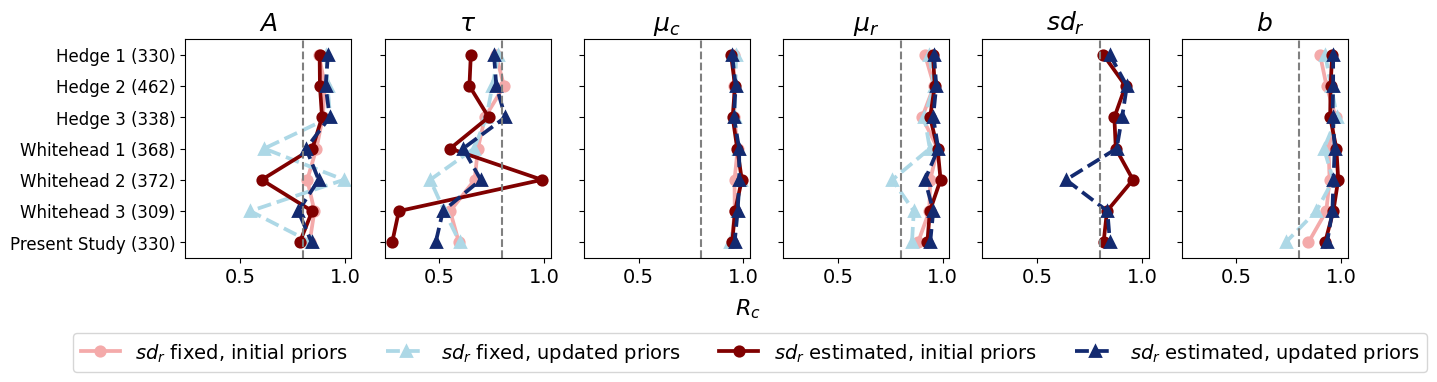

In [85]:
fontsize = 14

custom_palette = {
    '$sd_r$ fixed, updated priors': "#add8e6",
    '$sd_r$ estimated, updated priors': "#132a70",
    '$sd_r$ fixed, initial priors': "#f4aaaa",
    '$sd_r$ estimated, initial priors': 'maroon'
}

hue_order = [
    '$sd_r$ fixed, initial priors',
    '$sd_r$ fixed, updated priors',
    '$sd_r$ estimated, initial priors',
    '$sd_r$ estimated, updated priors'
]

fig, axes = plt.subplots(1,6, figsize = (15,3), sharex=True)

for p, ax in zip(param_names, axes):

    if p == 'sd_r':
        data_plot = data[~np.isnan(data['sd_r_c'])]
    else:
        data_plot = data
        
    sns.pointplot(data=data_plot, x=p + '_c', y = 'data_set_name', hue = 'category', linestyles=['-', '--', '-', '--'], markers=['o','^', 'o', '^'],  palette=custom_palette, ax=ax, hue_order=hue_order)

    #ax.xticks(rotation=90)
    ax.set_ylabel('')
    ax.set_xlabel('')
    #plt.title('Reliability A')
    ax.legend(title = '')

    if p != 'A':
        ax.set_yticklabels([])

    suff = "$\\" if p in ["tau", "mu_c", "mu_r"] else "$"

    label = suff + p + "$"

    ax.set_title(label, fontsize=fontsize+4)

    ax.axvline(x=0.8, color='gray', linestyle='--') 

    if p != 'b':
        ax.legend_.remove()

    else:
        ax.legend(loc='upper center', bbox_to_anchor=(-2.6, -0.3), ncol=4, fontsize=fontsize)


    ax.tick_params(axis='x', labelsize=fontsize )  
    ax.tick_params(axis='y', labelsize=fontsize - 2)

fig.supxlabel('$R_c$', fontsize=fontsize+2, y=-0.06)
fig.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.savefig(parent_dir + '/plots/plots_reliability/reliability_A_multiple_datasets.png', dpi=300, bbox_inches='tight')